In [2]:
import pandas as pd


df = pd.read_csv("cub-labels.csv")
df

,index,has_bill_shape_dagger,has_bill_shape_hooked_seabird,has_bill_shape_all-purpose,has_bill_shape_cone,has_wing_color_brown,has_wing_color_grey,has_wing_color_yellow,has_wing_color_black,has_wing_color_white,...,has_crown_color_grey,has_crown_color_yellow,has_crown_color_black,has_crown_color_white,has_wing_pattern_solid,has_wing_pattern_spotted,has_wing_pattern_striped,has_wing_pattern_multi-colored,class,path
0,1,0,1,0,0,1,1,0,1,0,...,1,0,0,0,1,0,1,1,0,CUB_200_2011/images/001.Black_footed_Albatross...
1,2,0,1,0,0,1,1,0,1,0,...,1,0,0,0,1,0,1,1,0,CUB_200_2011/images/001.Black_footed_Albatross...
2,3,0,1,0,0,1,1,0,1,0,...,1,0,0,0,1,0,1,1,0,CUB_200_2011/images/001.Black_footed_Albatross...
3,4,0,1,0,0,1,1,0,1,0,...,1,0,0,0,1,0,1,1,0,CUB_200_2011/images/001.Black_footed_Albatross...
4,5,0,1,0,0,1,1,0,1,0,...,1,0,0,0,1,0,1,1,0,CUB_200_2011/images/001.Black_footed_Albatross...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11783,11784,0,0,1,0,1,1,1,0,0,...,1,0,0,1,1,0,0,1,199,CUB_200_2011/images/200.Common_Yellowthroat/Co...
11784,11785,0,0,1,0,1,1,1,0,0,...,1,0,0,1,1,0,0,1,199,CUB_200_2011/images/200.Common_Yellowthroat/Co...
11785,11786,0,0,1,0,1,1,1,0,0,...,1,0,0,1,1,0,0,1,199,CUB_200_2011/images/200.Common_Yellowthroat/Co...
11786,11787,0,0,1,0,1,1,1,0,0,...,1,0,0,1,1,0,0,1,199,CUB_200_2011/images/200.Common_Yellowthroat/Co...


In [18]:
atts = [c for c in df.columns if c.startswith("has_")][:-1]

In [21]:
corr = df[[*atts]].corr()


# Replace `inf` and `-inf` values with 0
corr.replace([float("inf"), -float("inf")], 0, inplace=True)

# Replace `NaN` values with 0
corr.fillna(0, inplace=True)

/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


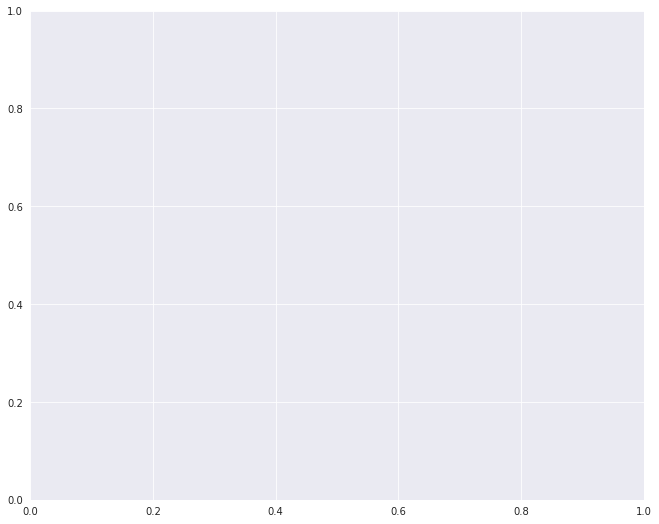

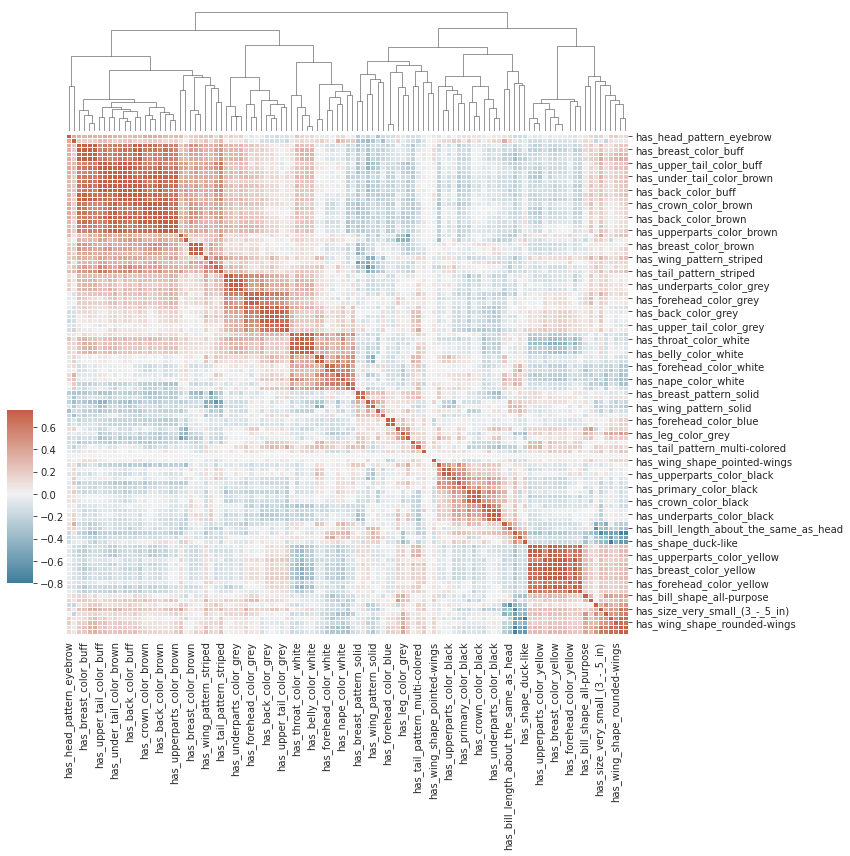

In [23]:
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sb.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
# sb.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
#             square=True, linewidths=.5, cbar_kws={"shrink": .5})

g = sb.clustermap(
    corr,
    cmap=cmap,
    # annot=True,
    # square=True,
    linewidths=0.5,
    center=0,
    vmax=0.75,
    figsize=(12, 12),
    cbar_pos=(0.02, 0.32, 0.03, 0.2),
    dendrogram_ratio=(0.1, 0.2),
)

g.ax_row_dendrogram.remove()
# plt.tight_layout(pad=0)
plt.savefig("/home/ki/correlations.pdf", bbox_inches="tight")

In [10]:
corr

,has_bill_shape_dagger,has_bill_shape_hooked_seabird,has_bill_shape_all-purpose,has_bill_shape_cone,has_wing_color_brown,has_wing_color_grey,has_wing_color_yellow,has_wing_color_black,has_wing_color_white,has_wing_color_buff,...,has_crown_color_blue,has_crown_color_brown,has_crown_color_grey,has_crown_color_yellow,has_crown_color_black,has_crown_color_white,has_wing_pattern_solid,has_wing_pattern_spotted,has_wing_pattern_striped,has_wing_pattern_multi-colored
has_bill_shape_dagger,1.000000,-0.136764,0.019684,-0.446584,-0.156668,-0.079269,-0.139398,0.001463,0.241562,-0.145446,...,-0.066078,-0.088834,-0.128333,-0.109892,0.255382,-0.000550,-0.035971,0.350266,-0.108117,-0.231734
has_bill_shape_hooked_seabird,-0.136764,1.000000,-0.319190,-0.291563,-0.103518,-0.007218,-0.155012,0.022644,0.025074,-0.160344,...,-0.092616,-0.113730,0.038547,-0.108062,-0.121011,0.390274,0.275644,-0.104417,-0.171727,-0.096694
has_bill_shape_all-purpose,0.019684,-0.319190,1.000000,0.029212,0.044918,0.032120,0.275604,-0.138657,-0.061125,0.042871,...,0.074652,0.100097,0.138037,0.158633,-0.064676,-0.298732,0.011852,0.111583,0.136880,0.022910
has_bill_shape_cone,-0.446584,-0.291563,0.029212,1.000000,0.008727,0.053245,0.139277,0.023440,-0.028510,0.114406,...,0.086087,0.036506,-0.015935,0.003162,0.015358,-0.147418,-0.231374,-0.194214,0.123847,0.254865
has_wing_color_brown,-0.156668,-0.103518,0.044918,0.008727,1.000000,0.165165,-0.120915,-0.038329,-0.040788,0.653327,...,-0.230061,0.631881,0.295909,-0.119741,-0.077750,-0.092375,-0.165053,0.132908,0.379247,-0.049675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
has_crown_color_white,-0.000550,0.390274,-0.298732,-0.147418,-0.092375,0.105888,-0.152255,0.019824,0.316794,0.032245,...,-0.132013,-0.171559,0.019485,-0.154029,-0.055857,1.000000,-0.015710,0.033583,-0.091630,0.084520
has_wing_pattern_solid,-0.035971,0.275644,0.011852,-0.231374,-0.165053,-0.080054,-0.093420,-0.251026,-0.471971,-0.189221,...,0.040481,-0.148150,-0.023081,-0.092128,0.046150,-0.015710,1.000000,-0.278750,-0.463457,-0.160972
has_wing_pattern_spotted,0.350266,-0.104417,0.111583,-0.194214,0.132908,-0.123494,-0.154475,0.124673,0.131084,0.197405,...,-0.092296,0.165914,0.006211,-0.059354,0.116187,0.033583,-0.278750,1.000000,0.233796,-0.318292
has_wing_pattern_striped,-0.108117,-0.171727,0.136880,0.123847,0.379247,0.289896,0.085456,0.110351,0.275244,0.378092,...,-0.037722,0.343114,0.216439,0.112640,-0.141230,-0.091630,-0.463457,0.233796,1.000000,0.129941


In [11]:
corr.isnull().any()

has_bill_shape_dagger             True
has_bill_shape_hooked_seabird     True
has_bill_shape_all-purpose        True
has_bill_shape_cone               True
has_wing_color_brown              True
                                  ... 
has_crown_color_white             True
has_wing_pattern_solid            True
has_wing_pattern_spotted          True
has_wing_pattern_striped          True
has_wing_pattern_multi-colored    True
Length: 112, dtype: bool